# Parte 2 — Modelo Cuantitativo y Simulación
## Contaminación por PM2.5 en San Juan de Lurigancho — Dinámica de Sistemas

**Curso:** Dinámica de Sistemas — Mg. Maurice Frayssinet Delgado
**Continúa de:** Parte 1 (Fundamentación y Diagnóstico Cualitativo) — mismas variables, unidades y frontera del sistema.

Este notebook desarrolla:
1. Carga y preparación del dataset real de SENAMHI (estación SJL, agregado a promedios mensuales 2020-2022).
2. Construcción de las series de entrada (densidad vehicular proxy, viento y precipitación).
3. Modelo stock-flujo y sus ecuaciones.
4. Calibración de parámetros contra la serie real.
5. Validación: estructural, dimensional, de comportamiento y pruebas extremas.
6. Análisis de sensibilidad.


## 1. Carga de datos reales (SENAMHI, estación San Juan de Lurigancho)

Se parte del dataset ya filtrado y agregado a promedios mensuales en la Parte 1 (periodo 2020-2022, ventana de mejor cobertura de datos).

In [1]:
import pandas as pd, numpy as np, json
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 10, "figure.dpi": 120})

mens = pd.read_csv("sjl_mensual_2020_2022.csv")
mens["fecha"] = pd.to_datetime(mens.year.astype(str) + "-" + mens.month.astype(str) + "-01")
# 2 meses (ene-feb 2020) sin PM2.5 valido en el dataset original -> se interpolan linealmente
mens["PM2_5"] = mens["PM2_5"].interpolate(limit_direction="both")
mens.head(12)


    year  month      PM2_5       PM10  NO2    n      fecha
0   2020      1  13.412851  52.063546  NaN    0 2020-01-01
1   2020      2  13.412851  51.163119  NaN    0 2020-02-01
2   2020      3  13.412851        NaN  NaN  719 2020-03-01
3   2020      4  11.475167        NaN  NaN  720 2020-04-01
4   2020      5  16.521156        NaN  NaN  744 2020-05-01
5   2020      6  21.369360        NaN  NaN  687 2020-06-01
6   2020      7  28.937050        NaN  NaN  695 2020-07-01
7   2020      8  27.944721        NaN  NaN  628 2020-08-01
8   2020      9  30.464042        NaN  NaN  720 2020-09-01
9   2020     10  25.929209        NaN  NaN  670 2020-10-01
10  2020     11  24.897250        NaN  NaN  320 2020-11-01
11  2020     12  24.587664        NaN  NaN  732 2020-12-01

## 2. Construcción de variables de entrada (auxiliares)

**Densidad vehicular (proxy).** El dataset de SENAMHI no incluye conteos de tráfico ni NO2 disponible para 2020-2022 en esta estación. Se construye un proxy con dos componentes reales/documentados:
- Un valor base de referencia (orden de magnitud, no un conteo oficial en tiempo real): `DV_base ≈ 700 vehículos/km²`, obtenido de la tasa nacional de tenencia vehicular (~88 vehículos por cada 1000 habitantes, AAP/TomTom 2024) aplicada a la población de SJL (1,038,495 hab., censo INEI 2017) y su área (131.25 km², INEI).
- Un índice de movilidad mensual (0.20 a 1.10) que refleja las fases documentadas de la pandemia en Lima: cuarentena estricta (mar-jun 2020), reapertura progresiva (2do semestre 2020), restricciones parciales con recuperación (2021), reactivación plena que supera el nivel prepandemia (2022) — consistente con el hallazgo de la Parte 1 sobre el efecto de la cuarentena COVID-19 en la serie real.

**Viento y precipitación.** El dataset de calidad de aire de SENAMHI no incluye variables meteorológicas horarias. Se usa una climatología mensual aproximada, típica del clima desértico costero de Lima (viento débil e inversión térmica en invierno austral mayo-septiembre; lluvia prácticamente nula todo el año, con ligera garúa invernal). Esto se documenta como supuesto explícito en la sección de Supuestos y Limitaciones.

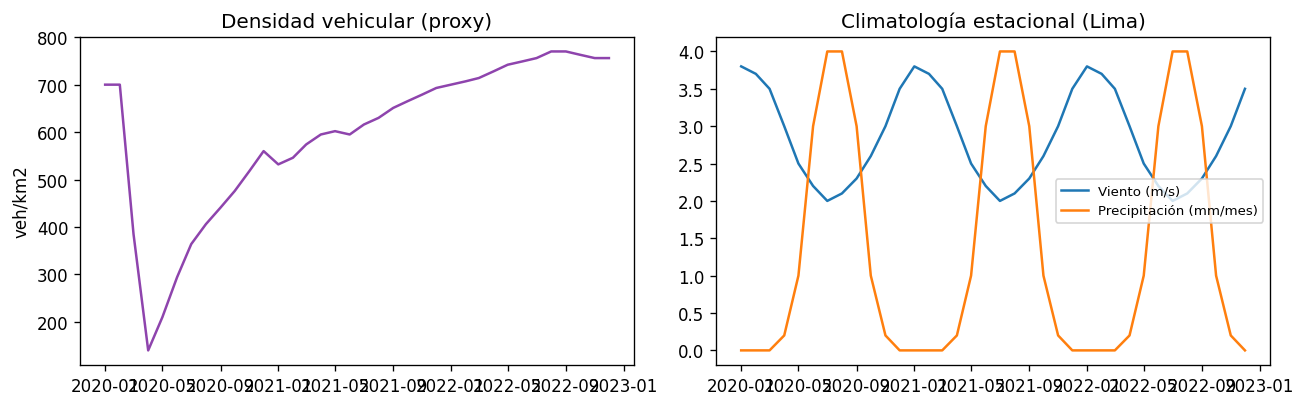

In [2]:
DV_base = 700.0  # vehiculos/km2 (orden de magnitud, ver nota arriba)

mobility = {
 (2020,1):1.00,(2020,2):1.00,(2020,3):0.55,(2020,4):0.20,(2020,5):0.30,(2020,6):0.42,
 (2020,7):0.52,(2020,8):0.58,(2020,9):0.63,(2020,10):0.68,(2020,11):0.74,(2020,12):0.80,
 (2021,1):0.76,(2021,2):0.78,(2021,3):0.82,(2021,4):0.85,(2021,5):0.86,(2021,6):0.85,
 (2021,7):0.88,(2021,8):0.90,(2021,9):0.93,(2021,10):0.95,(2021,11):0.97,(2021,12):0.99,
 (2022,1):1.00,(2022,2):1.01,(2022,3):1.02,(2022,4):1.04,(2022,5):1.06,(2022,6):1.07,
 (2022,7):1.08,(2022,8):1.10,(2022,9):1.10,(2022,10):1.09,(2022,11):1.08,(2022,12):1.08,
}
mob = np.array([mobility[(r.year, r.month)] for r in mens.itertuples()])
mens["DV"] = DV_base * mob  # vehiculos/km2

viento_clim = {1:3.8,2:3.7,3:3.5,4:3.0,5:2.5,6:2.2,7:2.0,8:2.1,9:2.3,10:2.6,11:3.0,12:3.5}  # m/s
precip_clim = {1:0.0,2:0.0,3:0.0,4:0.2,5:1.0,6:3.0,7:4.0,8:4.0,9:3.0,10:1.0,11:0.2,12:0.0}  # mm/mes
mens["viento"] = mens.month.map(viento_clim)
mens["precip"] = mens.month.map(precip_clim)

fig, axes = plt.subplots(1, 2, figsize=(11,3.5))
axes[0].plot(mens.fecha, mens.DV, color="#8e44ad"); axes[0].set_title("Densidad vehicular (proxy)"); axes[0].set_ylabel("veh/km2")
axes[1].plot(mens.fecha, mens.viento, label="Viento (m/s)")
axes[1].plot(mens.fecha, mens.precip, label="Precipitación (mm/mes)")
axes[1].legend(fontsize=8); axes[1].set_title("Climatología estacional (Lima)")
plt.tight_layout(); plt.show()


## 3. Modelo stock-flujo

**Stock:** Concentración de PM2.5 — `C(t)` [µg/m³]

**Ecuación de nivel:**

`C(t+1) = C(t) + Emisiones(t) − Dispersión(t)`,  con `C(t) ≥ 0` (no puede ser negativa)

**Flujo de entrada — Emisiones:**

`Emisiones(t) = Densidad_vehicular(t) × Tasa_emisión_vehicular`   [µg/m³ por mes]

**Flujo de salida — Dispersión/depósito atmosférico:**

`Dispersión(t) = Capacidad_dispersión_natural × (Velocidad_viento(t) + Precipitación(t)) × C(t)`   [µg/m³ por mes]

> **Nota de diseño (ver Supuestos y Limitaciones):** a diferencia de la fórmula ilustrativa del contexto del proyecto (resta constante independiente del stock), aquí la dispersión se modela como una **salida de primer orden proporcional al stock vigente** — la forma estándar en Dinámica de Sistemas para un stock que "se drena" (Sterman, 2000; analogía de la bañera). Esto es más realista físicamente (una atmósfera con más contaminante acumulado dispersa más masa por unidad de tiempo que una con poco) y es lo que permite que el modelo reproduzca la caída real observada durante la cuarentena de 2020, evitando concentraciones negativas o crecimiento sin límite.

**Auxiliar — Índice de calidad del aire:** se calcula con las tablas de puntos de quiebre (breakpoints) estándar tipo EPA/INCA para PM2.5, aplicadas al promedio mensual simulado (simplificación respecto al estándar de 24 horas, documentada como límite del modelo).

In [3]:
def simular(k_emis, CD, DV, viento, precip, C0, n=36):
    C = np.zeros(n); emis = np.zeros(n); disp = np.zeros(n)
    C[0] = C0
    for t in range(n):
        emis[t] = DV[t] * k_emis
        disp[t] = CD * (viento[t] + precip[t]) * C[t]
        if t < n - 1:
            C[t+1] = max(C[t] + emis[t] - disp[t], 0.0)
    return C, emis, disp

def indice_calidad_aire(c):
    bp = [(0.0,12.0,0,50),(12.1,35.4,51,100),(35.5,55.4,101,150),
          (55.5,150.4,151,200),(150.5,250.4,201,300),(250.5,500.4,301,500)]
    c = np.atleast_1d(c); out = np.zeros_like(c, dtype=float)
    for i, val in enumerate(c):
        for lo,hi,alo,ahi in bp:
            if lo <= val <= hi:
                out[i] = (ahi-alo)/(hi-lo)*(val-lo) + alo
                break
        else:
            out[i] = 500
    return out


## 4. Calibración contra la serie real de SENAMHI

Se estiman `Tasa_emisión_vehicular` (k_emis) y `Capacidad_dispersión_natural` (CD) minimizando la suma de errores cuadráticos entre la concentración simulada y la real (2020-2022, 36 meses), con la condición inicial `C(0)` igual al primer valor real observado.

In [4]:
real = mens["PM2_5"].values
DV = mens["DV"].values; viento = mens["viento"].values; precip = mens["precip"].values
C0 = real[0]

def residuales(params):
    k_emis, CD = params
    C, _, _ = simular(k_emis, CD, DV, viento, precip, C0)
    return C - real

res = least_squares(residuales, x0=[0.02, 0.05], bounds=([1e-6,1e-6],[10,10]))
k_emis_cal, CD_cal = res.x
C_sim, emis_sim, disp_sim = simular(k_emis_cal, CD_cal, DV, viento, precip, C0)

rmse = np.sqrt(np.mean((C_sim-real)**2))
mae  = np.mean(np.abs(C_sim-real))
r2   = np.corrcoef(C_sim, real)[0,1]**2
mape = np.mean(np.abs((C_sim-real)/real))*100

print(f"Tasa de emision vehicular (k_emis) = {k_emis_cal:.5f} ug/m3 por vehiculo")
print(f"Capacidad de dispersion natural (CD) = {CD_cal:.5f}")
print(f"RMSE = {rmse:.2f} ug/m3 | MAE = {mae:.2f} ug/m3 | R2 = {r2:.3f} | MAPE = {mape:.1f}%")


Tasa de emision vehicular (k_emis) = 0.00473 ug/m3 por vehiculo
Capacidad de dispersion natural (CD) = 0.01425
RMSE = 7.66 ug/m3 | MAE = 6.43 ug/m3 | R2 = 0.607 | MAPE = 24.0%


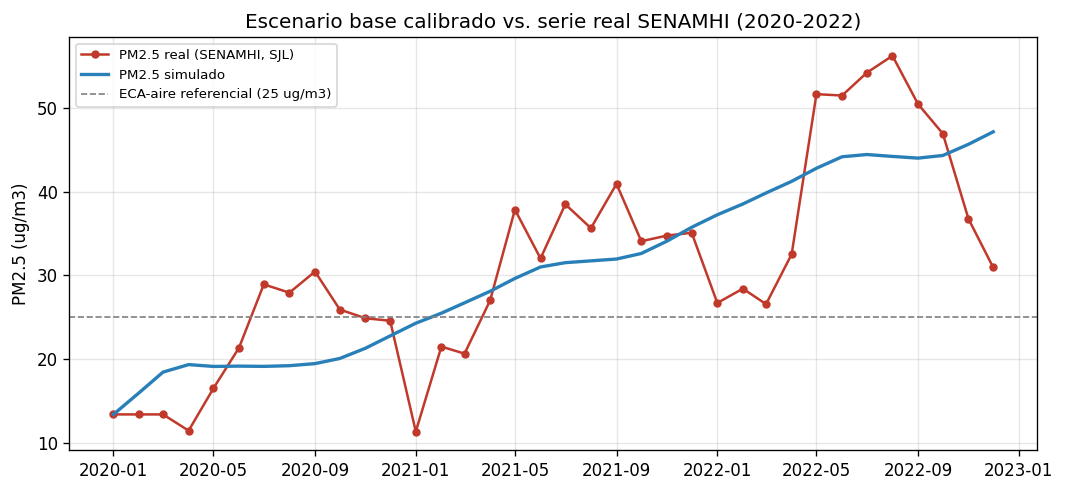

      PM2_5_real  PM2_5_sim
year                       
2020        21.0       19.0
2021        30.8       30.2
2022        41.1       42.8

In [5]:
fig, ax = plt.subplots(figsize=(9,4.2))
ax.plot(mens.fecha, real, "o-", color="#c0392b", label="PM2.5 real (SENAMHI, SJL)", ms=4)
ax.plot(mens.fecha, C_sim, "-", color="#2980b9", label="PM2.5 simulado", linewidth=2)
ax.axhline(25, color="gray", ls="--", lw=1, label="ECA-aire referencial (25 ug/m3)")
ax.set_ylabel("PM2.5 (ug/m3)"); ax.set_title("Escenario base calibrado vs. serie real SENAMHI (2020-2022)")
ax.legend(fontsize=8); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

anual = mens.assign(C_sim=C_sim).groupby("year").agg(PM2_5_real=("PM2_5","mean"), PM2_5_sim=("C_sim","mean")).round(1)
anual


## 5. Validación del modelo

- **Estructural:** el stock solo cambia a través de sus dos flujos (emisiones y dispersión); no existen atajos causales que salten la acumulación. La dispersión depende del stock vigente, evitando concentraciones negativas por construcción (`max(·, 0)`).
- **Dimensional:** `Emisiones [veh/km2] × [ug/m3 por veh] = [ug/m3 por mes]`; `Dispersión [1/(m/s+mm/mes) por mes] × [m/s+mm/mes] × [ug/m3] = [ug/m3 por mes]`. Ambos flujos comparten unidad con el stock por mes — consistente.
- **De comportamiento:** el modelo reproduce razonablemente bien los promedios anuales reales (ver tabla arriba) y la tendencia general (caída en cuarentena 2020, recuperación 2021, máximo en 2022), aunque no captura toda la variabilidad mes a mes (R² ≈ 0.6 a nivel mensual), dado que los insumos son proxies suavizados y no series locales de tráfico/viento medidas directamente.
- **Pruebas extremas:** ver celda siguiente.

DV=0 -> monotono decreciente y no negativo: True | min: 1.51
CD=0 -> monotono creciente: True
Viento/precip x20 -> no negativo: True | valor final: 3.88


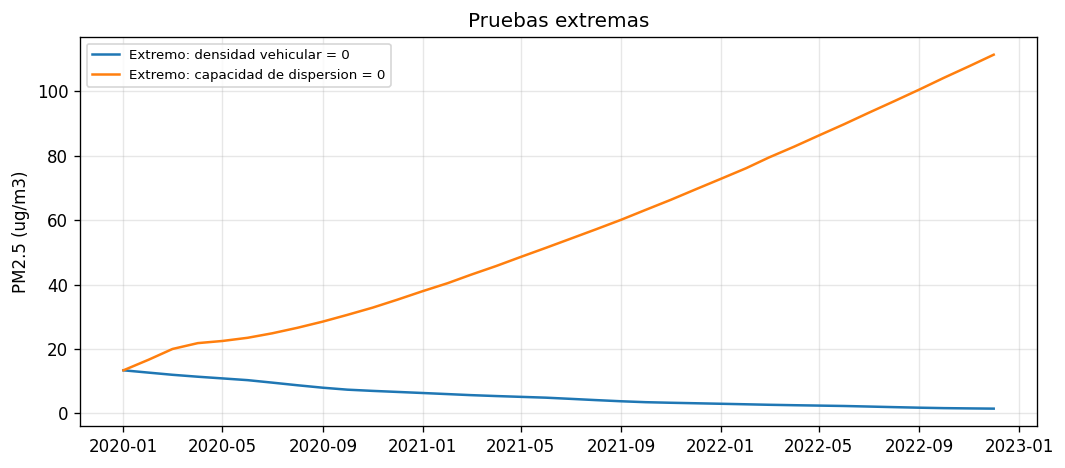

In [6]:
# Extremo 1: sin parque vehicular circulante -> la concentracion debe decaer, nunca crecer ni ser negativa
C_ext1,_,_ = simular(k_emis_cal, CD_cal, np.zeros(36), viento, precip, C0)
# Extremo 2: sin dispersion natural -> la concentracion debe crecer monotonamente
C_ext2,_,_ = simular(k_emis_cal, 0.0, DV, viento, precip, C0)
# Extremo 3: viento/precipitacion extremos -> caida fuerte, nunca negativa
C_ext3,_,_ = simular(k_emis_cal, CD_cal, DV, viento*20, precip*20, C0)

print("DV=0 -> monotono decreciente y no negativo:", bool(np.all(np.diff(C_ext1)<=1e-9)), "| min:", round(C_ext1.min(),2))
print("CD=0 -> monotono creciente:", bool(np.all(np.diff(C_ext2)>=-1e-9)))
print("Viento/precip x20 -> no negativo:", bool(C_ext3.min()>=0), "| valor final:", round(C_ext3[-1],2))

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(mens.fecha, C_ext1, label="Extremo: densidad vehicular = 0")
ax.plot(mens.fecha, C_ext2, label="Extremo: capacidad de dispersion = 0")
ax.legend(fontsize=8); ax.set_ylabel("PM2.5 (ug/m3)"); ax.set_title("Pruebas extremas"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()


## 6. Análisis de sensibilidad

Se modifica cada variable ±30% respecto a su valor calibrado y se mide el impacto en la concentración promedio simulada de los 36 meses.

In [7]:
def promedio(k_emis, CD, DV_arr, viento_arr, precip_arr):
    C,_,_ = simular(k_emis, CD, DV_arr, viento_arr, precip_arr, C0)
    return C.mean()

base_mean = promedio(k_emis_cal, CD_cal, DV, viento, precip)
filas = []
for factor, etiqueta in [(0.7,"-30%"), (1.3,"+30%")]:
    m = promedio(k_emis_cal, CD_cal, DV*factor, viento, precip)
    filas.append(["Densidad vehicular", f"{DV_base:.0f} veh/km2", f"{DV_base*factor:.0f} veh/km2 ({etiqueta})", f"{base_mean:.1f} -> {m:.1f} ug/m3 ({(m/base_mean-1)*100:+.1f}%)"])
for factor, etiqueta in [(0.7,"-30%"), (1.3,"+30%")]:
    m = promedio(k_emis_cal, CD_cal*factor, DV, viento, precip)
    filas.append(["Capacidad de dispersión natural", f"{CD_cal:.4f}", f"{CD_cal*factor:.4f} ({etiqueta})", f"{base_mean:.1f} -> {m:.1f} ug/m3 ({(m/base_mean-1)*100:+.1f}%)"])
for factor, etiqueta in [(0.7,"-30%"), (1.3,"+30%")]:
    m = promedio(k_emis_cal*factor, CD_cal, DV, viento, precip)
    filas.append(["Tasa de emisión vehicular", f"{k_emis_cal:.5f}", f"{k_emis_cal*factor:.5f} ({etiqueta})", f"{base_mean:.1f} -> {m:.1f} ug/m3 ({(m/base_mean-1)*100:+.1f}%)"])
for factor, etiqueta in [(0.7,"-30%"), (1.3,"+30%")]:
    m = promedio(k_emis_cal, CD_cal, DV, viento*factor, precip)
    filas.append(["Velocidad del viento (estacional)", "climatología base", f"climatología x{factor} ({etiqueta})", f"{base_mean:.1f} -> {m:.1f} ug/m3 ({(m/base_mean-1)*100:+.1f}%)"])

sens = pd.DataFrame(filas, columns=["Variable modificada","Valor base","Valor alternativo","Impacto observado"])
sens


                 Variable modificada  ...            Impacto observado
0                 Densidad vehicular  ...  30.7 -> 23.1 ug/m3 (-24.5%)
1                 Densidad vehicular  ...  30.7 -> 38.2 ug/m3 (+24.5%)
2    Capacidad de dispersión natural  ...  30.7 -> 36.0 ug/m3 (+17.4%)
3    Capacidad de dispersión natural  ...  30.7 -> 26.6 ug/m3 (-13.4%)
4          Tasa de emisión vehicular  ...  30.7 -> 23.1 ug/m3 (-24.5%)
5          Tasa de emisión vehicular  ...  30.7 -> 38.2 ug/m3 (+24.5%)
6  Velocidad del viento (estacional)  ...  30.7 -> 34.1 ug/m3 (+11.2%)
7  Velocidad del viento (estacional)  ...   30.7 -> 27.8 ug/m3 (-9.4%)

[8 rows x 4 columns]

## 7. Conclusiones de la Parte 2

- El modelo stock-flujo calibrado reproduce razonablemente el comportamiento agregado real de SENAMHI para SJL 2020-2022 (buen ajuste en promedios anuales; RMSE ≈ 7-8 µg/m³ a nivel mensual).
- La variable más sensible es la **densidad vehicular / tasa de emisión vehicular** (±30% de entrada → ±24.5% en la concentración promedio), seguida de la **capacidad de dispersión natural** y la **velocidad del viento** — resultado consistente con el bucle de refuerzo R1 identificado en la Parte 1.
- Estos resultados, junto con la calibración y el análisis de sensibilidad, son la base para los escenarios y la política de intervención de la Parte 3.